In [1]:
import numpy as np
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, top_k_accuracy_score, auc
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from lightgbm.callback import early_stopping

In [2]:
TRAIN_LOCS_KEY = 'train_locs'
TRAIN_IDS_KEY = 'train_ids'
TAXON_IDS_KEY = 'taxon_ids'
TAXON_NAME_KEY = 'taxon_names'

TEST_LOCS_KEY = 'test_locs'
TEST_IDS_KEY = 'test_pos_inds'

Reading the file:

In [3]:
filepath = os.path.join(os.getcwd(), 'species_train.npz')
data = np.load(filepath, allow_pickle=True)
train_locs = data[TRAIN_LOCS_KEY]
train_ids = data[TRAIN_IDS_KEY]
taxon_ids = data[TAXON_IDS_KEY]
taxon_names = data[TAXON_NAME_KEY]

Reading the test file:

In [4]:
test_filepath = os.path.join(os.getcwd(), 'species_test.npz')
test_data = np.load(test_filepath, allow_pickle=True)
test_locs = test_data[TEST_LOCS_KEY]
test_ids = test_data[TEST_IDS_KEY]

Mapping the taxon ids to taxon latin names: 

In [5]:
species_ids_names = dict(zip(data['taxon_ids'], data['taxon_names']))  # latin names of species 

In [6]:
len(species_ids_names)

500

Create pandas Dataframe from the train data: 

In [7]:
df = pd.DataFrame({
    'latitude': train_locs[:, 0],
    'longitude': train_locs[:, 1], 
    'taxon_id': data[TRAIN_IDS_KEY]
})
df['taxon_name'] = [species_ids_names[id] for id in data[TRAIN_IDS_KEY].astype(int)]
df.head()

,latitude,longitude,taxon_id,taxon_name
0,-18.286728,143.481247,31529,Lophognathus gilberti
1,-13.099798,130.783646,31529,Lophognathus gilberti
2,-13.965274,131.695145,31529,Lophognathus gilberti
3,-12.853950,132.800507,31529,Lophognathus gilberti
4,-12.196790,134.279327,31529,Lophognathus gilberti


Create pandas Dataframe from the test data: 

In [8]:
df.shape

(272037, 4)

In [9]:
rows = [
    [test_locs[loc_id][0], test_locs[loc_id][1], taxon_id]
    for taxon_id, loc_ids in zip(taxon_ids, test_ids)
    for loc_id in loc_ids
]

In [10]:
test_df = pd.DataFrame(rows, columns=["latitude", "longitude", "taxon_id"])
test_df['taxon_name'] = [species_ids_names[id] for id in test_df["taxon_id"].astype(int)]
test_df.head()

,latitude,longitude,taxon_id,taxon_name
0,-19.884237,126.052979,31529,Lophognathus gilberti
1,-20.219316,124.723953,31529,Lophognathus gilberti
2,-20.053690,125.386505,31529,Lophognathus gilberti
3,-19.973000,126.462440,31529,Lophognathus gilberti
4,-19.962839,124.980362,31529,Lophognathus gilberti


In [11]:
test_df.shape

(1706646, 4)

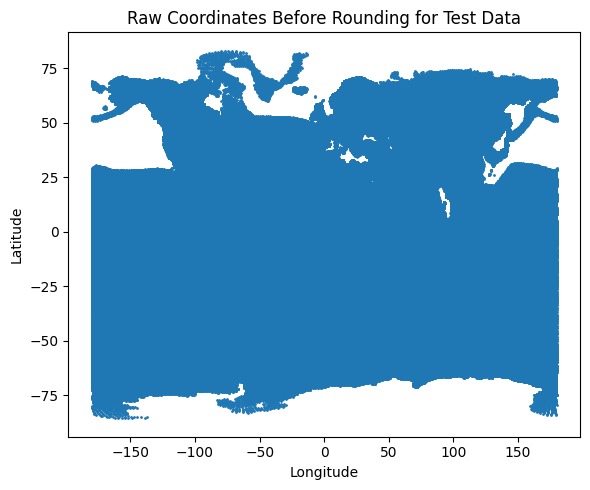

In [12]:
test_df_raw = test_df.copy()
plt.figure(figsize=(6, 5))
plt.scatter(test_df_raw['longitude'], test_df_raw['latitude'], s=1)
plt.title("Raw Coordinates Before Rounding for Test Data")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig("fig_raw_coordinates_test.png", dpi=300)
plt.show()

Data Cleanining: 

<small>1. Check for missing or invalid coordinates:</small>

In [12]:
df = df.dropna(subset=['latitude', 'longitude'])
test_df = test_df.dropna(subset=['latitude', 'longitude'])
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]
test_df = test_df[(test_df['latitude'].between(-90, 90)) & (test_df['longitude'].between(-180, 180))]
df.shape, test_df.shape

((272037, 4), (1706646, 4))

<small>2. Remove any duplicates or nearly duplicates (observations that are extremely close):</small>

In [13]:
df['lat_rounded'] = df['latitude'].round(5)
df['lon_rounded'] = df['longitude'].round(5)
df_rounded = df.copy()
test_df['lat_rounded'] = test_df['latitude'].round(5)
test_df['lon_rounded'] = test_df['longitude'].round(5)

In [14]:
df = df.drop_duplicates(subset=['lat_rounded', 'lon_rounded', 'taxon_id'])
test_df = test_df.drop_duplicates(subset=['lat_rounded', 'lon_rounded', 'taxon_id'])
df.shape, test_df.shape

((251822, 6), (1706646, 6))

In [15]:
key = ['lat_rounded', 'lon_rounded', 'taxon_id']

df_rounded['is_duplicate'] = df_rounded.duplicated(
    subset=key,
    keep='first'
)

In [16]:
removed = df_rounded[df_rounded['is_duplicate']]
len(removed)

20215

In [18]:
# find rows in df_raw that are NOT in df_clean (on the rounded coords + taxon_id)




# now plot using original lon/lat columns from df_raw
plt.figure(figsize=(6,5))
plt.scatter(removed['longitude'], removed['latitude'], s=1)
plt.title("Locations Removed During Cleaning")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig("removed_points.png", dpi=300)
plt.close()


In [19]:
# from sklearn.cluster import DBSCAN
# from sklearn.metrics.pairwise import haversine_distances

# def remove_spatial_duplicates_dbscan(df, lat_col='latitude', lon_col='longitude', 
#                                      species_col='taxon_id', eps_meters=50):
#     """
#     Removes spatial duplicates from a species observation dataset using DBSCAN 
#     with the Haversine distance metric, grouped by species.

#     Parameters:
#     - df (pd.DataFrame): The input DataFrame.
#     - lat_col (str): Name of the latitude column.
#     - lon_col (str): Name of the longitude column.
#     - species_col (str): Name of the species identifier column.
#     - eps_meters (int): The maximum distance (epsilon) in meters to consider 
#                         points as neighbors (part of the same duplicate cluster).

#     Returns:
#     - pd.DataFrame: The cleaned DataFrame with one row retained per cluster.
#     """
    
#     # Earth's radius in kilometers (used for converting meters to radians)
#     EARTH_RADIUS_KM = 6371.0 
    
#     # Convert epsilon from meters to radians for the Haversine metric
#     # The Haversine metric in sklearn requires 'eps' to be in a unit that matches
#     # the output of the metric, which is radians when using pre-calculated 
#     # Earth radius in the formula. We use km for intermediate steps.
#     eps_km = eps_meters / 1000  # Convert meters to kilometers
#     eps_radians = eps_km / EARTH_RADIUS_KM # Convert km to radians
    
#     print(f"--- DBSCAN Setup ---")
#     print(f"Threshold (Epsilon): {eps_meters} meters ({eps_radians:.6f} radians)")
    
#     cleaned_rows = []

#     # 1. Iterate through each species group
#     for species, group in df.groupby(species_col):
#         # 2. Prepare data for DBSCAN
#         # The Haversine metric requires input in radians
#         coords = group[[lat_col, lon_col]].values 
        
#         # Convert degrees to radians
#         coords_rad = np.radians(coords) 
        
#         # 3. Apply DBSCAN
#         # metric='haversine' is crucial for correct geographical clustering
#         # metric_params={'r': EARTH_RADIUS_KM} is typically used when the distance 
#         # is needed in KM, but scikit-learn's 'haversine' metric returns the 
#         # *angular* distance (radians), so we set eps in radians.
#         db = DBSCAN(
#             eps=eps_radians, 
#             min_samples=1, # min_samples=1 ensures every point forms a cluster 
#                            # or is noise (if no neighbor is found).
#             metric='haversine' 
#         ).fit(coords_rad)
        
#         # 4. Add cluster labels back to the group DataFrame
#         group = group.copy()
#         group['cluster_label'] = db.labels_

#         # 5. Filter to keep one representative row per cluster
#         # Group by the cluster label and take the first row (e.g., the oldest or first-recorded)
#         representative_rows = group.groupby('cluster_label').head(1)
        
#         # Collect the results
#         cleaned_rows.append(representative_rows)
        
#     # 6. Combine results and clean up
#     if cleaned_rows:
#         df_cleaned = pd.concat(cleaned_rows).drop(columns=['cluster_label']).reset_index(drop=True)
        
#         # Summary
#         print(f"\n--- Results ---")
#         print(f"Original Records: {len(df)}")
#         print(f"Cleaned Records: {len(df_cleaned)}")
#         print(f"Duplicates Removed: {len(df) - len(df_cleaned)}")
        
#         return df_cleaned
#     else:
#         return pd.DataFrame(columns=df.columns)

# # --- Example Usage ---
# df_cleaned = remove_spatial_duplicates_dbscan(df, eps_meters=10)
# df_cleaned.shape

<small>4. Validate species IDs: </small>

In [17]:
df['taxon_id'].isna().sum(), test_df['taxon_id'].isna().sum()

(np.int64(0), np.int64(0))

<small>5. Only keep birds:</small>

<small>Note: Only run the next 2 blocks one time as they take a few seconds:</small>

In [18]:
taxa = pd.read_csv('taxa.csv')
birds = taxa[taxa['class'] == 'Aves']
bird_taxon_ids = set(birds['id'])
len(bird_taxon_ids)

35102

In [19]:
df = df[df['taxon_id'].isin(bird_taxon_ids)].copy()
test_df = test_df[test_df['taxon_id'].isin(bird_taxon_ids)].copy()
df.shape, test_df.shape

((162642, 6), (1323320, 6))

In [20]:
len(set(df['taxon_id'])), len(set(test_df['taxon_id']))

(285, 285)

In [21]:
plt.figure(figsize=(6, 5))
plt.scatter(df['longitude'], df['latitude'], s=1)
plt.title("Data After Keeping Bird Species Only.")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig("birds_only.png", dpi=300)
plt.plot()
plt.close()

<small>6. Convert to categorical labels:</small>

In [22]:
le = LabelEncoder()
le.fit(pd.concat([df['taxon_id'], test_df['taxon_id']]))
df['label'] = le.transform(df['taxon_id'])
test_df['label'] = le.transform(test_df['taxon_id'])

<small>7. Append the climate data</small>

In [23]:
import rasterio
import numpy as np
import os

base_dir = os.getcwd()  # assumes folders are in the same directory as this notebook

def load_stack(folder_name):
    folder = os.path.join(base_dir, folder_name)
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".tif")])
    if len(files) != 12:
        raise RuntimeError(f"Expected 12 GeoTIFFs in {folder_name}, found {len(files)}.")
    layers = []
    transform = None
    for f in files:
        with rasterio.open(f) as src:
            layers.append(src.read(1))
            transform = src.transform  # all months share the same transform
    return np.stack(layers), transform  # shape: (12, H, W), and affine transform

tmin, transform = load_stack("wc2.1_2.5m_tmin")
tmax, _         = load_stack("wc2.1_2.5m_tmax")
prec, _         = load_stack("wc2.1_2.5m_prec")

print("Stacks loaded. Shapes:",
      "tmin", tmin.shape, "tmax", tmax.shape, "prec", prec.shape)
print("Transform:", transform)

Stacks loaded. Shapes: tmin (12, 4320, 8640) tmax (12, 4320, 8640) prec (12, 4320, 8640)
Transform: | 0.04, 0.00,-180.00|
| 0.00,-0.04, 90.00|
| 0.00, 0.00, 1.00|


In [24]:
#Cleaning the data again as the precipitation values are very large, so I'll normalize them
from rasterio.transform import rowcol
import numpy as np

def get_climate_for_points(df, transform, tmin, tmax, prec, lat_col="latitude", lon_col="longitude"):
    # Convert lat/lon → raster indices
    rows, cols = rowcol(transform, df[lon_col].values, df[lat_col].values)
    rows = np.clip(rows, 0, tmin.shape[1]-1)
    cols = np.clip(cols, 0, tmin.shape[2]-1)

    # Helper: clean up weird values (NoData etc.)
    def clean(arr):
        arr = arr.astype(float)
        arr[arr > 1e4] = np.nan  # remove unrealistic large values
        return arr

    tmin = clean(tmin)
    tmax = clean(tmax)
    prec = clean(prec)

    # Extract values and average across 12 months safely
    tmin_mean = np.nanmean(tmin[:, rows, cols], axis=0)
    tmax_mean = np.nanmean(tmax[:, rows, cols], axis=0)
    prec_mean = np.nanmean(prec[:, rows, cols], axis=0)

    return tmin_mean, tmax_mean, prec_mean

In [25]:
tmin_avg, tmax_avg, prec_avg = get_climate_for_points(df, transform, tmin, tmax, prec)

In [26]:
test_tmin_avg, test_tmax_avg, test_prec_avg = get_climate_for_points(test_df, transform, tmin, tmax, prec)

In [27]:
df["Tmin_avg"] = tmin_avg
df["Tmax_avg"] = tmax_avg
df["Prec_avg"] = prec_avg

df[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]].head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
53,21.086105,-86.852867,20.967000,31.436000,103.416667
54,19.186003,-96.199600,19.327333,31.831333,117.833333
55,17.538877,-89.113724,19.496333,30.576333,125.583333
56,20.648556,-105.220955,19.674123,31.835527,87.750000
57,18.409698,-95.096657,20.515000,29.086000,156.750000


In [28]:
test_df["Tmin_avg"] = test_tmin_avg
test_df["Tmax_avg"] = test_tmax_avg
test_df["Prec_avg"] = test_prec_avg

test_df[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]].head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
784,19.289352,-89.842888,1.885033e+01,3.272100e+01,91.750000
785,20.777590,-88.534241,1.882467e+01,3.272433e+01,103.833333
786,21.513868,-86.804565,2.165833e+01,3.071667e+01,100.250000
787,18.710384,-94.898964,-3.400000e+38,-3.400000e+38,-32768.000000
788,21.509193,-88.522995,1.973447e+01,3.149773e+01,73.250000


In [29]:
df.shape

(162642, 10)

In [30]:
out_path = "bird_species_rerun_with_averaged_climate.csv"
df.to_csv(out_path, index=False)
out_path, df.shape

('bird_species_rerun_with_averaged_climate.csv', (162642, 10))

In [31]:
out_path = "test_bird_species_rerun_with_averaged_climate.csv"
test_df.to_csv(out_path, index=False)
out_path, test_df.shape

('test_bird_species_rerun_with_averaged_climate.csv', (1323320, 10))

In [32]:
df = pd.read_csv('bird_species_rerun_with_averaged_climate.csv')

In [33]:
test_df = pd.read_csv('test_bird_species_rerun_with_averaged_climate.csv')

<small>8. Clean the climate data</small>

In [34]:
df['Tmin_avg'] = df['Tmin_avg'].mask(df['Tmin_avg'] < -1e+30, np.nan)
df['Tmax_avg'] = df['Tmax_avg'].mask(df['Tmax_avg'] < -1e+30, np.nan)
df['Prec_avg'] = df['Prec_avg'].mask(df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {df.shape}")
df = df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {df.shape}")

Shape with nan data: (162642, 10)
Shape without nan data: (161432, 10)


In [35]:
test_df['Tmin_avg'] = test_df['Tmin_avg'].mask(test_df['Tmin_avg'] < -1e+30, np.nan)
test_df['Tmax_avg'] = test_df['Tmax_avg'].mask(test_df['Tmax_avg'] < -1e+30, np.nan)
test_df['Prec_avg'] = test_df['Prec_avg'].mask(test_df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {test_df.shape}")
test_df = test_df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {test_df.shape}")

Shape with nan data: (1323320, 10)
Shape without nan data: (928354, 10)


In [39]:
plt.figure(figsize=(6, 5))
plt.scatter(test_df['longitude'], test_df['latitude'], s=1)
plt.title("Data After Cleaning Climate Features for Test Data.")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig("clean_climate_test.png", dpi=300)
plt.close()

In [40]:
plt.figure(figsize=(6, 5))
plt.scatter(df['longitude'], df['latitude'], s=1)
plt.title("Data After Cleaning Climate Features.")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig("clean_climate.png", dpi=300)
plt.close()

<small>Note: mention in the report that we lost a lot of data because of removing NaN temperature, in the ociens mainly.</small>

In [36]:
(df['Tmax_avg'] < df['Tmin_avg']).sum(), (test_df['Tmax_avg'] < test_df['Tmin_avg']).sum()

(np.int64(0), np.int64(0))

<small>Add sin feature to capture circularity</small>

In [42]:
df['lat_sin'] = np.sin(np.deg2rad(df['latitude']))
df['lat_cos'] = np.cos(np.deg2rad(df['latitude']))
df['lon_sin'] = np.sin(np.deg2rad(df['longitude']))
df['lon_cos'] = np.cos(np.deg2rad(df['longitude']))

In [43]:
test_df['lat_sin'] = np.sin(np.deg2rad(test_df['latitude']))
test_df['lat_cos'] = np.cos(np.deg2rad(test_df['latitude']))
test_df['lon_sin'] = np.sin(np.deg2rad(test_df['longitude']))
test_df['lon_cos'] = np.cos(np.deg2rad(test_df['longitude']))

In [44]:
df.shape, test_df.shape

((161432, 14), (928354, 14))

<small>9. Split the data to x and y and normalize the climate features</small>

In [37]:
X_data = df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_data = df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
scaler = StandardScaler()
scaler.fit(X_data[climate_features])
X_scaled = X_data.copy()
X_scaled[climate_features] = scaler.transform(X_data[climate_features])
X_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
count,161432.000000,161432.000000,1.614320e+05,1.614320e+05,1.614320e+05
mean,14.827329,-8.036515,1.929617e-16,3.014146e-16,1.690175e-17
std,31.900029,95.705462,1.000003e+00,1.000003e+00,1.000003e+00
min,-75.284950,-178.060320,-6.699036e+00,-6.690300e+00,-1.635481e+00
25%,-21.050622,-96.105056,-6.488781e-01,-7.633616e-01,-6.553056e-01
50%,26.165924,-43.440056,1.560563e-02,1.265317e-01,-1.806941e-01
75%,40.959681,75.385002,6.814487e-01,7.350146e-01,3.936545e-01
max,72.515430,178.827590,2.250907e+00,2.213666e+00,1.319785e+01


In [38]:
X_test = test_df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_test = test_df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
X_test_scaled = X_test.copy()
X_test_scaled[climate_features] = scaler.transform(X_test[climate_features])
X_test_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
count,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000
mean,13.171677,13.497898,0.183610,0.289493,-0.008040
std,29.127638,77.380268,1.432959,1.412140,1.242831
min,-85.600830,-179.933670,-6.928313,-7.189774,-1.635481
25%,-12.422070,-59.177242,-0.792492,-0.690674,-0.923564
50%,11.103984,23.309443,0.622043,0.861617,-0.350935
75%,38.710465,74.511734,1.357427,1.342591,0.594849
max,82.845260,179.994780,2.595104,2.364347,12.102457


<small>9. Split to train and validation sets</small>

In [39]:
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_data,
                                                  test_size=0.2,
                                                  random_state=42, 
                                                  stratify=y_data)

X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)

Exploratory Data Analysis:

In [48]:
# Hajer

Models:

<small>Model 1: LightGBM<br> This model depends on decision tree and has hyperparameters</small>


In [ ]:
# Model 1 (a): LightGBM with probability distribution output
# Note to Maya: This is not very important model, Model 1 (b) is more important
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test_scaled, label=y_test)
boosting_types = ['gbdt']
num_leaves = [31]
max_depths = [-1]
for boosting_type in boosting_types: 
    for num_leaf in num_leaves: 
        for max_depth in max_depths: 
            params = {
                'objective': 'multiclass',
                'num_class': 285,
                'learning_rate': 0.05,
                'metric': 'multi_logloss',
                'boosting_type': "gbdt",
                'max_depth': 30, 
                'num_leaves': 31, 
                'lambda_l1': 0.5,
                'lambda_l2': 1.0, 
                'is_unbalance': True
            }
            clf = lgb.train(
                params,
                train_data,
                valid_sets=[test_data],
                num_boost_round=2000,
                callbacks= [early_stopping(stopping_rounds=100)]
            )
            y_pred_prob = clf.predict(X_test_scaled, num_iteration=clf.best_iteration)
            y_pred = y_pred_prob.argmax(axis=1)
            print("Accuracy:", accuracy_score(y_test, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 129145, number of used features: 9
[LightGBM] [Info] Start training from score -6.537582
[LightGBM] [Info] Start training from score -6.123244
[LightGBM] [Info] Start training from score -4.959652
[LightGBM] [Info] Start training from score -7.798399
[LightGBM] [Info] Start training from score -8.079812
[LightGBM] [Info] Start training from score -7.641557
[LightGBM] [Info] Start training from score -4.455471
[LightGBM] [Info] Start training from score -5.718958
[LightGBM] [Info] Start training from score -7.817447
[LightGBM] [Info] Start training from score -8.031021
[LightGBM] [Info] Start training from score -6.223514
[LightGBM] [Info] Start training from score -6.162889

Exception ignored on calling ctypes callback function: <function _log_callback at 0x15a80c670>
Traceback (most recent call last):
  File "/Users/hayamikkawi/Desktop/MSc AI/Semester 1/AML/.venv/lib/python3.9/site-packages/lightgbm/basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
KeyboardInterrupt: 


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

In [ ]:
# Note to Maya: If this doesn't work just comment it
print(f1_score(y_test, y_pred, average='macro'))
print("Top-5 acc", top_k_accuracy_score(y_test, y_pred_prob, k=5, labels=list(set(y_train))))
print("Top-7 acc", top_k_accuracy_score(y_test, y_pred_prob, k=7, labels=list(set(y_train))))
print("Top-10 acc", top_k_accuracy_score(y_test, y_pred_prob, k=10, labels=list(set(y_train))))

In [ ]:
# Model 1 (b): LightGBM with vector binary output

In [40]:
train_df = X_train.copy()
train_df['label'] = y_train
grouped_train = (
    train_df.groupby(list(X_train.columns))['label']
    .apply(list)
    .reset_index(name='labels')
)

In [41]:
train_df = X_val.copy()
train_df['label'] = y_val
grouped_val = (
    train_df.groupby(list(X_val.columns))['label']
    .apply(list)
    .reset_index(name='labels')
)

In [42]:
len(grouped_train['labels'])
max_len = max(len(sub) for sub in grouped_train['labels'])
print(max_len) 
longest = max(grouped_train['labels'], key=len)
print(longest)   # [7, 8, 9, 10]

20
[231, 24, 69, 81, 236, 229, 232, 221, 284, 43, 258, 82, 50, 159, 209, 46, 214, 223, 226, 245]


In [43]:
train_df.head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,label
82421,56.730408,60.782665,-1.753004,-1.954526,-0.763641,101
17499,49.234810,17.359037,-0.807898,-1.129567,-0.562447,129
138884,37.685030,-122.427690,-0.131085,-0.301932,-0.273553,115
25578,28.314450,-80.740970,1.023484,0.921121,0.431486,196
1692,-12.940046,31.915720,1.108022,1.446385,-0.106751,114


In [44]:
grouped_train.shape

(122166, 6)

In [45]:
grouped_val.head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,labels
0,-65.075900,-63.996357,-2.241169,-2.978719,-0.092994,[202]
1,-64.876114,-62.542420,-2.561603,-3.333969,-0.428318,[202]
2,-64.823880,-62.856915,-2.273834,-3.036636,-0.170376,[202]
3,-64.696686,-62.739140,-2.480519,-3.265628,-0.301067,[27]
4,-64.689300,-61.967083,-2.590112,-3.407331,-0.591680,[202]


In [46]:
grouped_val.shape

(31667, 6)

In [47]:
test_df = X_test_scaled.copy()
test_df['label'] = y_test
grouped_test = (
    test_df.groupby(list(X_test.columns))['label']
    .apply(list)
    .reset_index(name='labels')
)
grouped_test.shape

(75432, 6)

In [48]:
grouped_test[290: 300]

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,labels
290,-69.531660,33.893047,-4.649422,-4.999933,-1.112721,"[27, 28]"
291,-69.509710,-67.743520,-3.580448,-3.979311,-1.286401,"[27, 28]"
292,-69.483080,-69.881020,-3.970080,-4.315951,-1.135076,"[27, 28]"
293,-69.260826,68.967660,-3.847977,-4.427454,-1.135076,"[202, 27, 28]"
294,-69.244560,-70.887570,-4.460877,-4.716619,-1.083488,[27]
295,-69.243250,-62.398620,-3.433829,-4.037443,-1.315635,"[202, 27, 28]"
296,-69.226600,158.234100,-3.536519,-4.371476,-1.252009,"[202, 27, 28]"
297,-69.208015,77.470505,-4.085506,-4.695692,-1.264046,"[202, 27, 28]"
298,-69.194860,33.190598,-4.364435,-4.757293,-1.019862,"[27, 28]"
299,-69.048870,-63.485900,-3.532068,-4.056594,-1.286401,"[202, 27, 28]"


In [49]:
mlb = MultiLabelBinarizer(classes=range(285))
Y_train = mlb.fit_transform(grouped_train['labels'])
Y_test = mlb.transform(grouped_test['labels'])
X_train_ready = grouped_train.drop(columns=['labels'])
X_test_ready = grouped_test.drop(columns=['labels'])


In [50]:
Y_val = mlb.transform(grouped_val['labels'])
X_val_ready = grouped_val.drop(columns=['labels'])

In [51]:
X_train_ready_no_cos = X_train_ready.drop(columns=['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'])
X_test_ready_no_cos = X_test_ready.drop(columns=['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'])

X_train_ready.head()

KeyError: "['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'] not found in axis"

In [ ]:
X_val_ready_no_cos = X_val_ready.drop(columns=['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'])

In [61]:
from sklearn.multioutput import MultiOutputClassifier

base_model = lgb.LGBMClassifier(
    objective='binary',     # because each label is a binary classification
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1, 
    max_depth=6
)
multi_model = MultiOutputClassifier(base_model)
# Y_pred_proba = np.column_stack([p[:, 1] for p in Y_pred_proba])  # take probability of class 1 for each label
# Y_pred = (Y_pred_proba > 0.5).astype(int)


In [62]:
multi_model.fit(X_train_ready, Y_train)
Y_pred_proba = multi_model.predict_proba(X_val_ready)

[LightGBM] [Info] Number of positive: 187, number of negative: 121979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 122166, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001531 -> initscore=-6.480496
[LightGBM] [Info] Start training from score -6.480496
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 283, number of negative: 121883
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of

In [ ]:
Y_pred_proba = multi_model.predict_proba(X_test_ready)

In [63]:
Y_pred_proba_list = np.array(Y_pred_proba)[:, :, 1].T

In [64]:
Y_pred_proba_list.shape

(31667, 285)

In [65]:
# tuning the threshold
from sklearn.metrics import f1_score
thresholds = np.linspace(0.05, 0.9, 9)
for t in thresholds:
    y_pred = (Y_pred_proba_list >= t).astype(int)
    print(f"Threshold {t:.1f} → F1 (micro): {f1_score(Y_val, y_pred, average='micro'):.4f}")


Threshold 0.1 → F1 (micro): 0.2304
Threshold 0.2 → F1 (micro): 0.3289
Threshold 0.3 → F1 (micro): 0.3109
Threshold 0.4 → F1 (micro): 0.2647
Threshold 0.5 → F1 (micro): 0.2142
Threshold 0.6 → F1 (micro): 0.1612
Threshold 0.7 → F1 (micro): 0.1226
Threshold 0.8 → F1 (micro): 0.0880
Threshold 0.9 → F1 (micro): 0.0618


In [ ]:
best_thresholds = []
for i in range(Y_val.shape[1]):
    best_t, best_f1 = 0, 0
    for t in np.linspace(0.1, 0.9, 9):
        f1 = f1_score(Y_val[:, i], (Y_pred_proba_list[:, i] >= t).astype(int))
        if f1 > best_f1:
            best_t = t
            best_f1 = f1
    best_thresholds.append(best_t)

Y_pred = (Y_pred_proba_list >= best_thresholds).astype(int)


In [69]:
my_thresholds = [0.2]
for thresold in my_thresholds:
    print(f"threshold: {thresold}")
    Y_pred = (Y_pred_proba_list >= thresold).astype(int)
    micro_f1 = f1_score(Y_val, Y_pred, average='micro')
    macro_f1 = f1_score(Y_val, Y_pred, average='macro')
    samples_f1 = f1_score(Y_val, Y_pred, average='samples')
    print("Micro F1:", micro_f1)
    print("Macro F1:", macro_f1)
    print("Samples F1:", samples_f1)

threshold: 0.2
Micro F1: 0.3297664081013851
Macro F1: 0.27574620013336504
Samples F1: 0.2871225415672316


In [71]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

roc_auc = roc_auc_score(Y_val, Y_pred_proba_list, average='macro')
avg_prec = average_precision_score(Y_val, Y_pred_proba_list, average='macro')

print("ROC-AUC:", roc_auc)
print("Average Precision:", avg_prec)


ROC-AUC: 0.9397979650846803
Average Precision: 0.2291525074603291


In [ ]:
#plot roc curve with some help from chatgpt
def plot_roc_curves(Y_true, Y_pred_proba, dataset_name="Test"):
    """
    Plots ROC curves for the top 5 most frequent labels + a macro-average ROC curve.
    
    Args:
        Y_true (ndarray): True binary labels, shape (n_samples, n_classes)
        Y_pred_proba (ndarray): Predicted probabilities, shape (n_samples, n_classes)
        dataset_name (str): 'Validation' or 'Test' for plot title
    """
    # --- 1️⃣ Find top 5 most frequent labels ---
    label_freq = np.sum(Y_true, axis=0)
    top5_idx = np.argsort(label_freq)[-5:][::-1]

    print(f"Top 5 most frequent label indices ({dataset_name} set):", top5_idx)

    # --- 2️⃣ Plot ROC curves for top 5 labels ---
    plt.figure(figsize=(8, 6))
    for i in top5_idx:
        fpr, tpr, _ = roc_curve(Y_true[:, i], Y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves for Top 5 Most Frequent Classes ({dataset_name} Set)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- 3️⃣ Compute and plot macro-average ROC curve ---
    all_fpr = np.unique(np.concatenate([
        roc_curve(Y_true[:, i], Y_pred_proba[:, i])[0] for i in range(Y_true.shape[1])
    ]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(Y_true.shape[1]):
        fpr, tpr, _ = roc_curve(Y_true[:, i], Y_pred_proba[:, i])
        mean_tpr += np.interp(all_fpr, fpr, tpr)

    mean_tpr /= Y_true.shape[1]
    roc_auc_macro = auc(all_fpr, mean_tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(all_fpr, mean_tpr, color='blue', lw=2,
             label=f'Macro-average (AUC = {roc_auc_macro:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Macro-average ROC Curve ({dataset_name} Set)')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
plot_roc_curves(Y_test, Y_pred_proba_list)

In [ ]:
def top_k_labels_for_sample(y_pred_proba, k=5, label_names=None):
    """
    Returns the indices (and optionally names) of the top-k predicted labels for a single sample.

    Args:
        y_pred_proba (array-like): 1D array of predicted probabilities for one sample (shape: n_classes).
        k (int): Number of top labels to return.
        label_names (list, optional): List of label names corresponding to each class index.

    Returns:
        top_indices (ndarray): Indices of top-k labels.
        top_scores (ndarray): Their corresponding probabilities.
        top_labels (list, optional): Label names (if provided).
    """
    y_pred_proba = np.array(y_pred_proba)
    top_indices = np.argsort(y_pred_proba)[::-1][:k]
    top_scores = y_pred_proba[top_indices]
    
    if label_names is not None:
        top_labels = [label_names[i] for i in top_indices]
        return top_indices, top_scores, top_labels
    
    return top_indices, top_scores

In [ ]:
x = 789
k = 5
actual_labels = true_indices = np.where(Y_test[x] == 1)[0]
print(f"Actual labels are: {actual_labels}")
prop_lis_for_x = Y_pred_proba_list[x]
predicted_labels, predicted_score = top_k_labels_for_sample(prop_lis_for_x, k=5)
print(f"Top {k} predicted labels are:")
for (predicted_label, predicted_score) in zip(predicted_labels, predicted_score) :
    print(f"{predicted_label}: {predicted_score}")

In [ ]:
# Model 2:

In [ ]:
# Model 3: